# Surviving the tail: meeting the market

In the [simulation lab](narrative_evt_simulations.ipynb) we established, on data whose ground truth we set ourselves, how incredibily hard can be to measure a tail. Here, we impact on the market. We do not know even if these is a groudn truth. Do not worry, we shall navigate this sea together!

Our guiding atlas is going to be the  **the checklist** which we produced at the end of the simulation notebook. Its nine commandments read, briefly (more or less): (i) you shall never report a tail statistic without its sample size *in the tail*; (ii) you shall always check moment existence before using a moment; (iii) you shall always ask where the tail begins, not just what its exponent is; (iv) you shall never trust a single Hill plateau; (v) you shall always report $\xi$, not $\alpha$; (vi) you shall use profile-likelihood intervals; (vii) you shall treat every concentration and shortfall measure as a lower bound; (viii) you shall score risk models on $Z_2$, not on exception counts; and (ix) you shall size on the tail, and compute the wipeout leverage explicitly.

We shall use all of this to work with S&P data and pay our debt to [Quant-RMT-FatTails](https://github.com/MarcoGaloppo/Quant-RMT-FatTails). Namely, we wish to anwer the question: **does covariance cleaning reduce tail risk, or only variance?**

Our astute plan:

**The data (Part 0).** The same panel as the RMT lab (so that every comparison with the previous project is like for like) plus the conventions that keep our good tails intact.

**Diagnosis (Part 1).** Here we run on our own market preasimpotitc machinery (see Chapter 10 of Taleb's SCoFT): MAD/STD, max-to-sum, kurtosis under aggregation, empirical $\kappa$, excess conditional expectation, records, and the asymmetry between the two tails. 

Everything runs on `evt_lab.py`, the same module the simulation notebook used.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import importlib, evt_lab                    # we are still editing the module:
importlib.reload(evt_lab)                    # pick up edits without a kernel restart

from evt_lab import (
    mad, mad_over_std, max_to_sum_ratio, kappa_bootstrap, kurtosis_under_aggregation,
    survival_empirical, local_alpha, excess_conditional_ratio,
    block_maxima, fit_gev, gev_return_level,
    mean_excess, exceedances, fit_gpd, gpd_profile_ci, threshold_stability, pot_var_es,
    hill, hill_plot, pickands, dedh_moment, pareto_mle_alpha, alpha_hat_moments,
    var_es_empirical, var_es_gaussian, es_var_ratio, alpha_from_es_var_ratio, es_sigma_ratio,
    extremal_index, decluster, stationary_bootstrap,
    drawdown, max_drawdown, quantile_contribution,
    sample_cov, eigh_desc, clean_cov, min_var_weights, day_scale,
)

SEED = 20260907
rng = np.random.default_rng(SEED)
pd.set_option("display.width", 200)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10, "axes.titlesize": 11,
    "legend.frameon": False,
})
C0, C1, C2, C3, C4 = "C0", "C1", "C2", "C3", "C4"

DATA_DIR = os.path.abspath("data")           # gitignored cache
os.makedirs(DATA_DIR, exist_ok=True)
GAUSS_MADSTD = np.sqrt(2 / np.pi)            # 0.7979, the reference we keep returning to
GAUSS_ES_SD = 2.6652                         # ES99/sigma for a Gaussian
print("toolkit loaded; cache dir:", DATA_DIR)

toolkit loaded; cache dir: /sessions/tender-modest-fermi/mnt/Quant_Preparation/EVT-FatTails-PreAsymptotics/data


## Part 0 — The data, and the rules that keep a tail alive

Three principles, inherited from the previous lab and more load-bearing here than they were there.

**1. No winsorising. Anywhere. Ever.** Every risk system in production clips or truncates extreme
observations somewhere, usually silently, usually justified as "removing outliers". In a
thin-tailed world that is a defensible variance-reduction trick. In this world **the outliers are
the subject**. Winsorising a fat tail does not clean the data, it deletes the finding.

**2. Log returns by default, net returns where money is summed.** $r = \ln(P_t/P_{t-1})$ is
additive through time, which is what we need for aggregation, drawdowns and compounding.
$(P_t - P_{t-1})/P_{t-1}$ is additive across assets, which is what we need for portfolios. Confusing
the two is a small error in the body and a large one in the tail, since the two disagree by
$O(r^2)$.

**3. Per-window completeness, never forward-filling.** A forward-filled price manufactures a zero
return followed by a double-sized one — precisely the pattern that fattens a measured tail. We
instead require a name to have a complete history over whatever window we are using, and drop it
from that window otherwise.

The universe is the previous lab's, unchanged: about 220 liquid S&P names tagged by sector, plus a
cross-asset futures panel. Keeping it identical is the point — Part 5 has to compare like with
like.

In [2]:
UNIVERSE = {
    "Info Tech": ["AAPL","MSFT","NVDA","AVGO","ORCL","CRM","ADBE","AMD","QCOM","TXN",
                  "INTC","INTU","IBM","CSCO","ACN","AMAT","MU","LRCX","KLAC","ADI",
                  "SNPS","CDNS","PANW","ANET","NOW","APH","MSI","GLW","HPQ","NXPI"],
    "Comm Svcs": ["GOOGL","META","NFLX","DIS","CMCSA","VZ","T","TMUS","CHTR","EA",
                  "TTWO","OMC"],
    "Financials": ["BRK-B","JPM","BAC","WFC","C","GS","MS","SCHW","BLK","BX","KKR",
                   "AXP","V","MA","COF","USB","PNC","TFC","BK","AIG","MET","PRU",
                   "ALL","TRV","CB","PGR","MMC","AON","SPGI","MCO","ICE","CME"],
    "Health Care": ["LLY","UNH","JNJ","ABBV","MRK","PFE","TMO","ABT","DHR","AMGN",
                    "GILD","BMY","MDT","ISRG","SYK","BSX","VRTX","REGN","CI","ELV",
                    "CVS","HUM","BDX","EW","A","IDXX","MCK","HCA","ZTS"],
    "Cons Disc": ["AMZN","TSLA","HD","MCD","NKE","SBUX","LOW","TJX","BKNG","MAR",
                  "HLT","GM","F","ROST","YUM","CMG","ORLY","AZO","EBAY","DHI",
                  "LEN","RCL"],
    "Cons Staples": ["PG","KO","PEP","COST","WMT","PM","MO","MDLZ","CL","KMB","GIS",
                     "SYY","KR","STZ","HSY","TGT","DG","DLTR","EL"],
    "Energy": ["XOM","CVX","COP","SLB","EOG","MPC","PSX","VLO","OXY","HAL","WMB",
               "KMI","OKE","DVN","BKR"],
    "Industrials": ["CAT","DE","HON","UNP","UPS","FDX","BA","LMT","RTX","NOC","GD",
                    "GE","MMM","EMR","ETN","ITW","PH","CMI","CSX","NSC","WM","RSG",
                    "PCAR","ROK","DOV","AME","URI","PWR"],
    "Materials": ["LIN","APD","SHW","ECL","FCX","NEM","NUE","DD","PPG","VMC","MLM"],
    "Utilities": ["NEE","DUK","SO","D","AEP","EXC","SRE","XEL","ED","PEG","WEC","ES"],
    "Real Estate": ["PLD","AMT","CCI","EQIX","SPG","O","PSA","WELL","DLR","AVB"],
}
SECTOR_OF = {t: s for s, ts in UNIVERSE.items() for t in ts}
TICKERS = sorted(SECTOR_OF)

CROSS_ASSET = {
    "Equity idx":  ["ES=F", "NQ=F", "YM=F", "RTY=F", "EFA", "EEM"],
    "Rates":       ["ZB=F", "ZN=F", "ZF=F", "ZT=F", "TLT", "IEF", "SHY"],
    "Credit":      ["LQD", "HYG"],
    "Metals":      ["GC=F", "SI=F", "HG=F", "GLD", "SLV"],
    "Energy":      ["CL=F", "BZ=F", "NG=F", "RB=F", "HO=F", "XLE"],
    "Ags":         ["ZC=F", "ZS=F", "ZW=F", "KC=F", "SB=F", "CC=F", "CT=F"],
    "FX":          ["6E=F", "6J=F", "6B=F", "6A=F", "6C=F", "6S=F", "DX=F", "UUP"],
    "Real assets": ["VNQ", "DBC"],
}
CLASS_OF = {t: c for c, ts in CROSS_ASSET.items() for t in ts}
XA_TICKERS = sorted(CLASS_OF)
START = "2010-01-01"

print(f"{len(TICKERS)} equity names across {len(UNIVERSE)} sectors; "
      f"{len(XA_TICKERS)} cross-asset instruments across {len(CROSS_ASSET)} classes")

220 equity names across 11 sectors; 43 cross-asset instruments across 8 classes


In [3]:
FORCE_REFRESH = False

def _download(tickers, start, label):
    try:
        import io, logging, contextlib
        import yfinance as yf
        logging.getLogger("yfinance").setLevel(logging.CRITICAL)
        with contextlib.redirect_stderr(io.StringIO()):        # yahoo failures are noisy
            raw = yf.download(tickers, start=start, auto_adjust=True,
                              progress=False, threads=True)
        px = raw["Close"] if "Close" in raw else raw
        px = px.sort_index().dropna(axis=1, how="all") if px.ndim == 2 else px.sort_index()
        if px.empty:
            raise RuntimeError("download returned nothing")
        return px
    except Exception as e:
        print(f"  [{label}] OFFLINE or download failed ({type(e).__name__}).")
        return None

def fetch(name, tickers, start, force=False):
    """Cache-first. Returns None if we have neither a cache nor a connection."""
    path = os.path.join(DATA_DIR, f"{name}.parquet")
    if not force and os.path.exists(path):
        px = pd.read_parquet(path)
        n = px.shape[1] if px.ndim == 2 else 1
        print(f"  [{name}] cache: {n} series x {len(px)} days "
              f"({px.index[0].date()} to {px.index[-1].date()})")
        return px
    px = _download(tickers, start, name)
    if px is None:
        return None
    (px.to_frame() if px.ndim == 1 else px).to_parquet(path)
    n = px.shape[1] if px.ndim == 2 else 1
    print(f"  [{name}] downloaded and cached: {n} series x {len(px)} days")
    return px

px = fetch("sp_prices", TICKERS, START, FORCE_REFRESH)
pxa = fetch("cross_asset_prices", XA_TICKERS, START, FORCE_REFRESH)
# The long index history. EVT wants exceedances, and 4,000 days do not supply many;
# Part 2 uses this when it exists and says so loudly when it does not.
spx_long = fetch("gspc_long", "^GSPC", "1927-12-30", FORCE_REFRESH)
if spx_long is None:
    print("  [gspc_long] absent -> Part 2 will run on the 2010- window and flag the fact.\n"
          "              Run this cell once with a network connection to build it.")

  [sp_prices] cache: 218 series x 4193 days (2010-01-04 to 2026-09-03)
  [cross_asset_prices] cache: 42 series x 4197 days (2010-01-04 to 2026-09-04)
  [gspc_long] cache: 1 series x 24787 days (1927-12-30 to 2026-09-04)


Now,  before a single tail is fitted we look at what the data actually contains.

Then, **we name our data objects and fix what each one is for.** There are four of them and they are not interchangeable.

In [4]:
first_valid = px.apply(lambda s: s.first_valid_index())
full = (first_valid == px.index[0]).sum()
report = pd.DataFrame({"first date": first_valid.dt.date,
                       "missing %": (100 * px.isna().mean()).round(2),
                       "sector": pd.Series(SECTOR_OF)}).sort_values("first date")

print(f"equity panel : {px.shape[1]} names x {px.shape[0]} days "
      f"({px.index[0].date()} to {px.index[-1].date()})")
print(f"               overall missing {100 * px.isna().mean().mean():.2f}%, "
      f"{full}/{px.shape[1]} names with a complete history")
print(f"not delivered: {sorted(set(TICKERS) - set(px.columns)) or 'none'}")
print("\nlatest listings — these sit out the early windows and must never be forward-filled:")
display(report.tail(6))

equity panel : 218 names x 4193 days (2010-01-04 to 2026-09-03)
               overall missing 1.75%, 200/218 names with a complete history
not delivered: ['BK', 'MMC']

latest listings — these sit out the early windows and must never be forward-filled:


,first date,missing %,sector
HLT,2013-12-12,23.68,Cons Disc
ANET,2014-06-06,26.54,Info Tech
EA,2026-07-17,99.86,Comm Svcs
AVB,2026-07-17,99.36,Real Estate
BK,NaN,NaN,Financials
MMC,NaN,NaN,Financials


**The data cleaning works.**  We remove 6 names. Of these, the last two would really create problems if forward-filled. But we are safe.

In [5]:
# ---- returns -----------------------------------------------------------------
# Log by default: additive through time, which is what aggregation, drawdowns and
# compounding need. Net where money is summed across assets (Part 5).
lr = np.log(px).diff().iloc[1:]                  # (T, N) panel log returns
nr = px.pct_change(fill_method=None).iloc[1:]    # (T, N) panel net returns
lr_xa = np.log(pxa).diff()

# ---- OBJECT 1: THE PANEL. 218 individual stocks. The primary object of this lab,
#      and the identical object the RMT lab built its correlation matrices from.
PANEL = lr

# ---- OBJECT 2: THE MARKET. ^GSPC, the S&P 500 cash index, 98 years.
#      The only series here that contains 1929, 1987 and 2008. Used whenever we
#      want "the market" rather than "a stock", and required by Part 2.
MKT = -np.log(spx_long.iloc[:, 0].dropna()).diff().dropna() if spx_long is not None else None
MKT_WIN = MKT[MKT.index >= px.index[0]] if MKT is not None else None   # matched 2010- window

# ---- OBJECTS 3 and 4: THE CONTROLS. Neither is used to draw a conclusion; both
#      exist so that claims about OBJECT 2 can be cross-checked against series with
#      different failure modes.
CTRL_FUT = -lr_xa["ES=F"].dropna()               # e-mini futures: tradeable, but 23h/day,
                                                 #   so it books crisis moves across sessions
CTRL_EW = -np.log1p(nr.mean(axis=1, skipna=True)).dropna()   # equal-weight PORTFOLIO of the panel
                                                 #   (net across assets, THEN log)

roster = pd.DataFrame(
    [["PANEL",    "218 stocks, log returns",        f"{lr.shape[1]} x {lr.shape[0]}",
      "Parts 1a, 4, 5"],
     ["MKT",      "^GSPC cash index, losses, 98y",  f"1 x {len(MKT)}" if MKT is not None else "absent",
      "Parts 1b, 2, 3"],
     ["MKT_WIN",  "^GSPC, matched 2010- window",    f"1 x {len(MKT_WIN)}" if MKT is not None else "absent",
      "Part 1c comparison"],
     ["CTRL_FUT", "ES=F e-mini futures, losses",    f"1 x {len(CTRL_FUT)}", "control only"],
     ["CTRL_EW",  "equal-weight portfolio, losses", f"1 x {len(CTRL_EW)}", "control only"]],
    columns=["name", "what it is", "shape", "used in"]).set_index("name")
display(roster)

if MKT is not None:
    common = pd.concat([MKT_WIN.rename("MKT_WIN"), CTRL_FUT.rename("CTRL_FUT"),
                        CTRL_EW.rename("CTRL_EW")], axis=1).dropna()
    print(f"the market and its two controls, on {len(common)} common days:")
    display(pd.DataFrame({
        "correlation with MKT_WIN": common.corr()["MKT_WIN"],
        "ann. vol": common.std() * np.sqrt(252),
        "worst day": common.max(),
        "worst day on": [common[c].idxmax().date() for c in common.columns],
    }).round(4))

,what it is,shape,used in
name,,,
PANEL,"218 stocks, log returns",218 x 4192,"Parts 1a, 4, 5"
MKT,"^GSPC cash index, losses, 98y",1 x 24786,"Parts 1b, 2, 3"
MKT_WIN,"^GSPC, matched 2010- window",1 x 4194,Part 1c comparison
CTRL_FUT,"ES=F e-mini futures, losses",1 x 4192,control only
CTRL_EW,"equal-weight portfolio, losses",1 x 4192,control only


the market and its two controls, on 4188 common days:


,correlation with MKT_WIN,ann. vol,worst day,worst day on
MKT_WIN,1.0000,0.1723,0.1277,2020-03-16
CTRL_FUT,0.9741,0.1733,0.1096,2020-03-16
CTRL_EW,0.9661,0.1722,0.1310,2020-03-16


Let us be very clear here about our roster:

1. **The `PANEL` is the primary object.** It is made up by the 218 individual stocks (a priori), and it is *the identical object the RMT lab used*. EVT is univariate, so we do have to choose a series, but there is no reason for that choice to displace the panel. Indeed, the panel has
no weighting decision, no roll, no index-inclusion rules, and it is made up of **218 samples of the tail question rather than one**. 

2. **`MKT` is the market, and it exists for one reason the panel cannot supply: length.** Our panel starts in 2010 and so contains no 1929, no 1987, no 2008. `^GSPC` has $24{,}786$ days back to 1928. 

3. **`CTRL_FUT` and `CTRL_EW` draw no conclusions.** They exist because these are measurements that do not share a failure mode. `ES=F` is tradeable but trades nearly 23 hours a day, so its close-to-close books a crisis across two sessions; `^GSPC` only exists 9:30-16:00 and books it in one. The equal-weight portfolio has neither roll nor index rules but is synthetic and ignores costs. All three correlate above $0.94$ and agree
on the worst day, which is what we wanted to know. They are *not* interchangeable in the tail, as the futures come out visibly thinner, purely from the overnight window.

Now, I repeat, the object this notebook is about is **the market** (`MKT`, 98 years), and specifically its tail. Let us start looking at it.

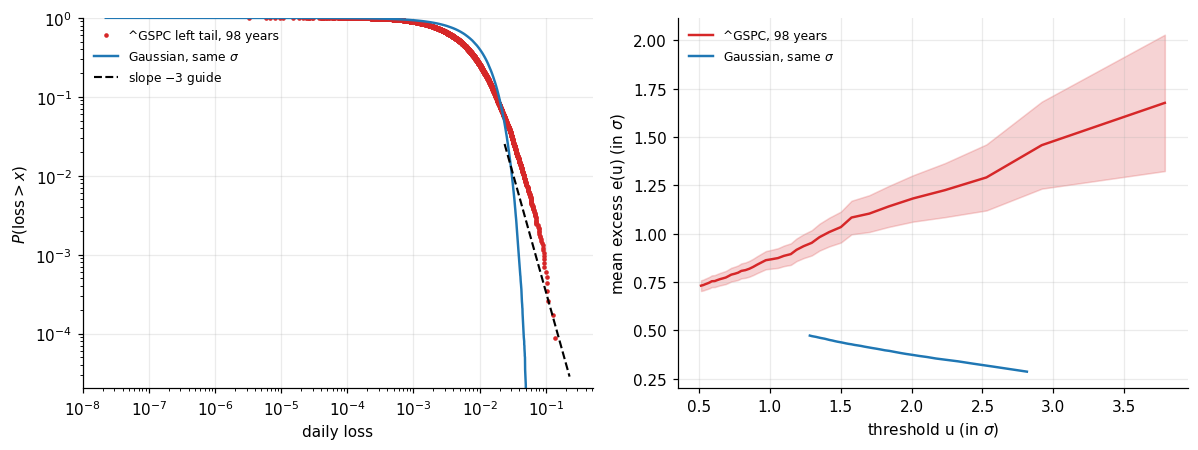

MKT: 24786 days (98 years), sigma = 0.0119
  beyond 3 sd: observed 226   a Gaussian would give 33.459
  beyond 4 sd: observed 106   a Gaussian would give 0.785
  beyond 5 sd: observed  56   a Gaussian would give 0.007
  beyond 6 sd: observed  29   a Gaussian would give 0.000
  worst: 22.90% = 19.2 sd   (a Gaussian's largest in 24786 draws would be about 4.1 sd)
  mean-excess slope: market +0.297   Gaussian -0.124


In [6]:
L0 = MKT.values                                     # THE MARKET, 98 years, losses
sd0 = L0.std()

fig, (ax1, ax2) = plt.subplots(1, 2)
xs_, s_ = survival_empirical(L0[L0 > 0])
ax1.loglog(xs_, s_, "o", ms=2, color=C3, label="^GSPC left tail, 98 years")
gl = np.abs(np.random.default_rng(3).standard_normal(400_000) * sd0)
xg, sg = survival_empirical(gl)
ax1.loglog(xg, sg, "-", lw=1.6, color=C0, label=f"Gaussian, same $\\sigma$")
grid = np.logspace(np.log10(2 * sd0), np.log10(L0.max()), 50)
ax1.loglog(grid, (grid / (2 * sd0)) ** -3.0 * float(np.mean(L0 > 2 * sd0)),
           "--", lw=1.4, color="k", label=r"slope $-3$ guide")
ax1.set(xlabel="daily loss", ylabel=r"$P(\mathrm{loss} > x)$", ylim=(1 / len(L0) / 2, 1))
ax1.legend(fontsize=8)

u_, e_, se_, n_ = mean_excess(L0, np.quantile(L0, np.linspace(.80, .995, 40)))
ax2.plot(u_ / sd0, e_ / sd0, "-", color=C3, lw=1.6, label="^GSPC, 98 years")
ax2.fill_between(u_ / sd0, (e_ - 2 * se_) / sd0, (e_ + 2 * se_) / sd0, color=C3, alpha=.2)
ug, eg, _, _ = mean_excess(gl, np.quantile(gl, np.linspace(.80, .995, 40)))
ax2.plot(ug / sd0, eg / sd0, "-", color=C0, lw=1.6, label="Gaussian, same $\\sigma$")
ax2.set(xlabel=r"threshold u (in $\sigma$)", ylabel=r"mean excess e(u) (in $\sigma$)")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

from scipy.stats import norm as _n
print(f"MKT: {len(L0)} days ({len(L0)/252:.0f} years), sigma = {sd0:.4f}")
for m in (3, 4, 5, 6):
    print(f"  beyond {m} sd: observed {int((L0 > m*sd0).sum()):>3}   "
          f"a Gaussian would give {len(L0)*_n.sf(m):.3f}")
print(f"  worst: {100*L0.max():.2f}% = {L0.max()/sd0:.1f} sd   "
      f"(a Gaussian's largest in {len(L0)} draws would be about 4.1 sd)")
print(f"  mean-excess slope: market {np.polyfit(u_/sd0, e_/sd0, 1)[0]:+.3f}   "
      f"Gaussian {np.polyfit(ug/sd0, eg/sd0, 1)[0]:+.3f}")

The plot above show **the market, over ninety-eight years and how fat tailed is it.** The Gaussian with the *same variance* falls off a cliff whilst the data do not. The data seem to follow more the guiding $\alpha = 3$ slope if anything else.

To be more specific, we can just look at the counts. In $24{,}786$ days we see **$226$ losses beyond $3\sigma$** where a Gaussian allows $33$, **$106$ beyond $4\sigma$** against $0.8$, and **$56$ beyond $5\sigma$** against $0.007$. That last is a once-in-four-hundred-year event under the Gaussian and there are fifty-six of them. The worst day is $19.2\sigma$.

**The right panel is the mean excess plot which we always appreciate (lovely, really)** In such a plot, a GPD tail has $e(u) = (\beta + \xi u)/(1-\xi)$, linear in $u$ with slope $\xi/(1-\xi)$: flat means exponential, downward means a finite endpoint, upward means heavy. The market slopes go *up* ($+0.297$), roughly linearly from about $2\sigma$ onward. 

Of course, remember to **not read the slope as an estimate**. Inverting $\xi/(1-\xi) = 0.297$ gives $\xi = 0.229$, i.e., $\alpha \approx 4.4$ , way thinner than the slope $-3$ guide the left panel just matched. The line was obtained across thresholds from the $80$th percentile up, so most of its leverage comes from the *body*, where the local exponent has not converged. **The exponent is a function of where you look, and a global fit looks mostly in the wrong place.**

## Part 1 — Diagnosing the market

Here, we run both on the `PANEL` and the `MKT` the preasymptotics toolkit we investigated. In particular:

| test | question | verdict |
| :-- | :-- | :-- |
| MAD/STD | is $\sigma$ inflated by extremes? | not thin-tailed |
| max-to-sum $R_n(p)$ | is the $p$-th moment usable *here*? | usability |
| kurtosis under aggregation | does the CLT bites us? | only with a fixed block count |
| empirical $\kappa$ | how much slower than $\sqrt{n}$? | biased toward thin, it gives a lower bound |
| $E[X \mid X>K]/K$ | is the tail scale-free? | flat = power law, decaying = thin |
| records | more extremes than i.i.d. allows? | weak; wide null |
| Hill, both tails | what is $\alpha$? | with error bars, and never one $k$ |

### 1a — The typical stock

We directly run the whole battery across the cross-section of the `PANEL`. Every name gets its own $\kappa$, its own $R_4$, its
own $\hat\alpha$. We then report the *distribution*, and the pooled estimate (whereever pooling is legitimate, that is).

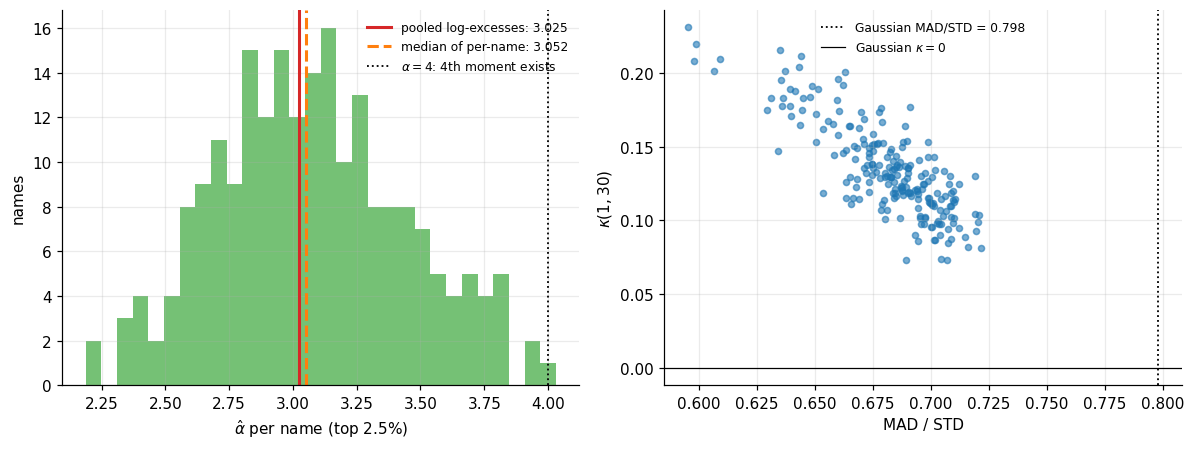

,MAD/STD,R4,alpha (Hill),ES99/sd left,"kappa(1,30)"
count,216.000,216.000,216.000,216.000,216.000
mean,0.681,0.267,3.071,4.020,0.134
std,0.024,0.177,0.373,0.268,0.031
min,0.595,0.050,2.187,3.386,0.073
10%,0.646,0.107,2.609,3.685,0.098
50%,0.685,0.201,3.052,4.016,0.129
90%,0.708,0.523,3.575,4.344,0.180
max,0.722,0.965,4.031,4.810,0.231


below the Gaussian MAD/STD of 0.7979 : 216/216
kappa(1,30) > 0                    : 216/216
R4 > 0.10 (one day owns >10% of the 4th-moment sum): 199/216
alpha < 4 (no fourth moment)       : 215/216;  alpha < 3: 97

pooled alpha over 22,276 log-excesses = 3.025 +/- 0.020
median of the per-name alphas             = 3.052
mean of the per-name alphas               = 3.071   <- do not use this

the five fattest names by R4:


,sector,R4,alpha (Hill)
ticker,,,
DHR,Health Care,0.965,3.148
OXY,Energy,0.921,2.689
SNPS,Info Tech,0.896,3.117
EQIX,Real Estate,0.883,3.065
DG,Cons Staples,0.743,2.665


In [7]:
rows, pooled_excess = [], []
for t in PANEL.columns:
    s = PANEL[t].dropna().values
    if len(s) < 1000:                                  # EA and AVB fail this, by design
        continue
    x = np.sort(np.abs(s))[::-1]
    k = max(30, len(x) // 40)                          # top 2.5% of each name
    rows.append({"ticker": t, "sector": SECTOR_OF.get(t, "?"), "n": len(s),
                 "MAD/STD": mad_over_std(s),
                 "R4": max_to_sum_ratio(s, 4)[-1],
                 "alpha (Hill)": 1.0 / (np.mean(np.log(x[:k])) - np.log(x[k])),
                 "ES99/sd left": es_sigma_ratio(-s, .01),
                 "kappa(1,30)": kappa_bootstrap(s, n=30, n0=1, reps=6_000,
                                                rng=np.random.default_rng(1))})
    pooled_excess.append(np.log(x[:k]) - np.log(x[k]))

xs = pd.DataFrame(rows).set_index("ticker")
pooled = np.concatenate(pooled_excess)
alpha_pooled = 1.0 / pooled.mean()
se_pooled = alpha_pooled / np.sqrt(pooled.size)

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.hist(xs["alpha (Hill)"], bins=30, color=C2, alpha=.65)
ax1.axvline(alpha_pooled, color=C3, lw=2, label=f"pooled log-excesses: {alpha_pooled:.3f}")
ax1.axvline(xs["alpha (Hill)"].median(), color=C1, lw=2, ls="--",
            label=f"median of per-name: {xs['alpha (Hill)'].median():.3f}")
ax1.axvline(4, color="k", ls=":", lw=1.2, label=r"$\alpha=4$: 4th moment exists")
ax1.set(xlabel=r"$\hat\alpha$ per name (top 2.5%)", ylabel="names")
ax1.legend(fontsize=8)
ax2.scatter(xs["MAD/STD"], xs["kappa(1,30)"], s=16, c=C0, alpha=.6)
ax2.axvline(GAUSS_MADSTD, color="k", ls=":", lw=1.2, label=r"Gaussian MAD/STD = 0.798")
ax2.axhline(0, color="k", ls="-", lw=.8, label=r"Gaussian $\kappa = 0$")
ax2.set(xlabel="MAD / STD", ylabel=r"$\kappa(1,30)$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

display(xs[["MAD/STD", "R4", "alpha (Hill)", "ES99/sd left", "kappa(1,30)"]]
        .describe(percentiles=[.1, .5, .9]).round(3))
print(f"below the Gaussian MAD/STD of {GAUSS_MADSTD:.4f} : {(xs['MAD/STD'] < GAUSS_MADSTD).sum()}/{len(xs)}")
print(f"kappa(1,30) > 0                    : {(xs['kappa(1,30)'] > 0).sum()}/{len(xs)}")
print(f"R4 > 0.10 (one day owns >10% of the 4th-moment sum): {(xs['R4'] > .10).sum()}/{len(xs)}")
print(f"alpha < 4 (no fourth moment)       : {(xs['alpha (Hill)'] < 4).sum()}/{len(xs)};  "
      f"alpha < 3: {(xs['alpha (Hill)'] < 3).sum()}")
print(f"\npooled alpha over {pooled.size:,} log-excesses = {alpha_pooled:.3f} +/- {se_pooled:.3f}")
print(f"median of the per-name alphas             = {xs['alpha (Hill)'].median():.3f}")
print(f"mean of the per-name alphas               = {xs['alpha (Hill)'].mean():.3f}   <- do not use this")
print("\nthe five fattest names by R4:")
display(xs.nlargest(5, "R4")[["sector", "R4", "alpha (Hill)"]].round(3))

**We looked at two 216 names of the S&P500, and not one of them is thin. They are all fat-tailed.** 

To wit, we see that:

- **$216/216$ have MAD/STD below the Gaussian $0.798$**, with median $0.685$.
- **$216/216$ have $\kappa(1,30) > 0$**, with median $0.129$ and minimum $0.073$. Not a single name in the S&P aggregates at Gaussian speed.
- **$199/216$ have $R_n(4) > 0.10$**. This means that for the typical name a single day out of four thousand owns a fifth of its entire fourth-moment sum (median $R_4 = 0.201$).
- **$215/216$ have $\hat\alpha < 4$**. As such the fourth moment does not seem to exist for essentially the whole panel, and $97$ have $\hat\alpha < 3$.
- The median $\mathrm{ES}_{99}/\sigma$ is $4.02$ and the *minimum across all names* is $3.39$. **There is no stock in this panel for which a Gaussian expected shortfall is even approximately right.**

Moreover, from pooling $22{,}276$ log-excesses we find:

$$\hat\alpha \;=\; 3.03 \pm 0.02 .$$

Here, we draw our attention again at *how* that is computed. As we saw in the simulation lab's (PArt 5) $\hat\alpha$ is inverse-gamma distributed, so its mean is dragged by the small-$\alpha$ draws: **pool the log-excesses, never average the alphas.** Here mean-of-alphas ($3.071$) and pooled ($3.025$) differ
by only $1.5\%$ because we have many names and long histories. But on a smaller panle we would be in trouble. Furthermore, we have to stress that in computing the error of $\pm 0.02$ we are treating the $218$ names as independent. They, of course, are not. We will get back to this.

Finally, just cause it is honestly astoneshing, **the fat-tail champion deserves a look on its own.** DHR shows $R_4 = 0.965$. Think about that number for a second. One day out of $4{,}193$ accounts for **96.5%** of its fourth-moment sum, so its (if) measured kurtosis of $160$ is a description of that single day and nothing else. However, note that the Hill $\hat\alpha$, which is built on logs and on the top $2.5\%$ rather than on a fourth power, is a perfectly ordinary $3.15$. That on its own is interesting.

### 1b — The market

EVT is a univariate game. And a long one. The market is ninety-eight years. On the other hand our panel starts in 2010 and therefore contains no 1929, no 1987, no 2008, as instead `^GSPC` does.

Of course, huge warning sign here. Ninety-eight years spans no circuit breakers, fixed commissions, the 1930s and decimalisation. Therefore, treating this whole span as one stationary sample assumes something nobody (me included) believes. We use it to *see* events the panel cannot, and we run the 2010- window alongside so that every claim can be checked against a matched period. A double check if you will.

,n,MAD/STD,R4,ES99/sd,worst day (sd),"kappa(1,30)"
series,,,,,,
^GSPC 1927- (98y),24786,0.6378,0.2522,4.3753,19.1950,0.2138
^GSPC 2010- (16y),4194,0.6606,0.2788,4.1637,11.7639,0.1813
Gaussian control,24786,0.7973,0.0076,2.6629,4.8791,0.0006


kurtosis under aggregation — with 98 years there is finally enough data to hold m fixed:


,lags,market,Gaussian control
blocks m,,,
1000,"[1, 5, 20]","[10.7, 7.53, 12.86]","[2.91, 2.93, 3.11]"
200,"[1, 5, 20, 60, 120]","[4.41, 5.06, 7.31, 6.42, 5.74]","[2.7, 2.56, 2.75, 2.87, 3.58]"


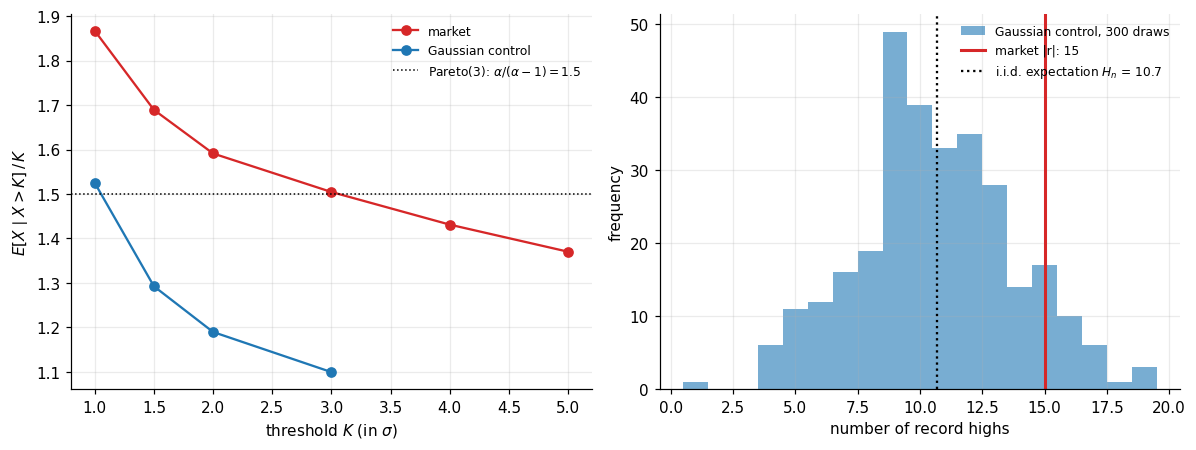

,market,Gaussian control,Pareto(3) theory
K / sigma,,,
1.0,1.867,1.525,1.5
1.5,1.689,1.293,1.5
2.0,1.591,1.190,1.5
3.0,1.504,1.099,1.5
4.0,1.431,NaN,1.5
5.0,1.370,NaN,1.5


records: market |r| = 15, i.i.d. expectation 10.70; Gaussian control median 10, 90% range [5, 16] -> market at the 93th percentile
worst day: 22.90% (19.2 sd) in 98y, vs 12.77% (11.8 sd) in the 2010- window


In [8]:
Lg = MKT.values          # OBJECT 2: the market, ^GSPC, 98 years of losses
Lm = MKT_WIN.values      # the same index restricted to the panel's 2010- window
NG, sdg = len(Lg), Lg.std()
GCL = np.random.default_rng(11).standard_normal(NG)                 # fixed Gaussian control

rows = [{"series": nm, "n": len(s), "MAD/STD": mad_over_std(s),
         "R4": max_to_sum_ratio(s, 4)[-1], "ES99/sd": es_sigma_ratio(s, .01),
         "worst day (sd)": s.max() / s.std(),
         "kappa(1,30)": kappa_bootstrap(s, n=30, n0=1, reps=40_000,
                                        rng=np.random.default_rng(1))}
        for nm, s in (("^GSPC 1927- (98y)", Lg), ("^GSPC 2010- (16y)", Lm),
                      ("Gaussian control", GCL))]
display(pd.DataFrame(rows).set_index("series").round(4))

print("kurtosis under aggregation — with 98 years there is finally enough data to hold m fixed:")
rows = [{"blocks m": B, "lags": str(lags),
         "market": np.round(kurtosis_under_aggregation(Lg, lags, blocks=B), 2),
         "Gaussian control": np.round(kurtosis_under_aggregation(GCL, lags, blocks=B), 2)}
        for B, lags in ((1000, [1, 5, 20]), (200, [1, 5, 20, 60, 120]))]
display(pd.DataFrame(rows).set_index("blocks m"))

mult = [1, 1.5, 2, 3, 4, 5]
ecr = pd.DataFrame({"K / sigma": mult,
                    "market": excess_conditional_ratio(Lg, [m * sdg for m in mult]),
                    "Gaussian control": excess_conditional_ratio(np.abs(GCL) * sdg,
                                                                 [m * sdg for m in mult]),
                    "Pareto(3) theory": [1.5] * len(mult)}).set_index("K / sigma")

def n_records(x):
    return int(np.sum(np.diff(np.maximum.accumulate(x)) > 0)) + 1

H_n = np.log(NG) + 0.5772156649
sim = np.array([n_records(np.abs(np.random.default_rng(700 + s).standard_normal(NG)))
                for s in range(300)])

fig, (ax1, ax2) = plt.subplots(1, 2)
for c_, lab in ((C3, "market"), (C0, "Gaussian control")):
    ax1.plot(mult, ecr[lab], "o-", color=c_, label=lab)
ax1.axhline(1.5, color="k", ls=":", lw=1, label=r"Pareto(3): $\alpha/(\alpha-1)=1.5$")
ax1.set(xlabel=r"threshold $K$ (in $\sigma$)", ylabel=r"$E[X \mid X>K]\,/\,K$")
ax1.legend(fontsize=8)
ax2.hist(sim, bins=np.arange(sim.min() - .5, sim.max() + 1.5), color=C0, alpha=.6,
         label="Gaussian control, 300 draws")
ax2.axvline(n_records(np.abs(Lg)), color=C3, lw=2, label=f"market |r|: {n_records(np.abs(Lg))}")
ax2.axvline(H_n, color="k", ls=":", lw=1.5, label=f"i.i.d. expectation $H_n$ = {H_n:.1f}")
ax2.set(xlabel="number of record highs", ylabel="frequency")
ax2.legend(fontsize=8, loc = 'best')
plt.tight_layout(); plt.show()
display(ecr.round(3))
print(f"records: market |r| = {n_records(np.abs(Lg))}, i.i.d. expectation {H_n:.2f}; Gaussian control "
      f"median {np.median(sim):.0f}, 90% range [{np.percentile(sim,5):.0f}, {np.percentile(sim,95):.0f}] "
      f"-> market at the {100*np.mean(sim <= n_records(np.abs(Lg))):.0f}th percentile")
print(f"worst day: {100*Lg.max():.2f}% ({Lg.max()/sdg:.1f} sd) in 98y, "
      f"vs {100*Lm.max():.2f}% ({Lm.max()/Lm.std():.1f} sd) in the 2010- window")

A lot of results. Let us go through them slowly (I also get lost if not!)

**1. $\kappa$ understates how slow the convergence is.** The bootstrap $\kappa$ resamples days that happened, so it cannot see the days that did not. Thus, it is biased toward thin tails. The 16-year window gives $\kappa(1,30) = 0.181$, the same index over 98 years gives $0.214$. **Six times the data, uniformly higher $\kappa$.** Therefore, every $\kappa$ is only a floor.

**2. Kurtoisis aggregation work well on such a big sample.** With $24{,}786$ days and $1{,}000$ blocks the Gaussian control tightens to $2.91$-$3.11$, i.e., the instrument is genuinely reliable at this sample size. It would not be $n = 4{,}192$. We see that the market gives $10.7 \to 7.53 \to 12.86$ across $k = 1, 5, 20$, i.e., **no convergence at all.** Aggregating to the monthly frequency does not make the market Gaussian.

**3. Looking at $E[X \mid X>K]/K$ gives us estimates for $\alpha$ without fitting anything.**  We now that by looking at this statistics, a Gaussian must collapse toward $1$, jsut as we see in the control $1.53 \to 1.29 \to 1.19 \to 1.10$, before running out of data entirely past $3\sigma$. A Pareto tail
would sit flat at $\alpha/(\alpha-1)$ forever. The market does neither. It reads $1.87, 1.69, 1.59, 1.50, 1.43, 1.37$ at $K = 1, 1.5, 2, 3, 4, 5\sigma$ — decaying, but *far* more slowly than the Gaussian. By inverting each value we can derive a *local* exponent of $\alpha \approx 3.0$ at $3\sigma$, $3.3$ at $4\sigma$, $3.7$ at $5\sigma$, i.e., a slow drift **upward in $\alpha$ as we move outward**. To wit, it looks like the far tail is slightly *thinner* than the near tail. 

**4. The exceedence test remains a weak one.** The market produces $15$ records against an i.i.d. expectation of $10.7$, and a Gaussian control whose 90% range is $[5, 16]$. This can be understood by the fact that records of excedeences grow like $\ln n$ under any continuous i.i.d. law, so the test is comparing two logarithms and has almost no power. **Not every instrument in a toolkit deserves equal weight.**

Now, the point that can make us cry a bit (and if I am sizing a portfolio I would worry about). The worst day in the 16-year window is $-12.8\%$ ($11.8\sigma$).But in the long record it is $-22.9\%$ ($19.2\sigma$). This is really bad.

Now, let us look at the asymmetry in tails, extremal indeces, and aggregation.

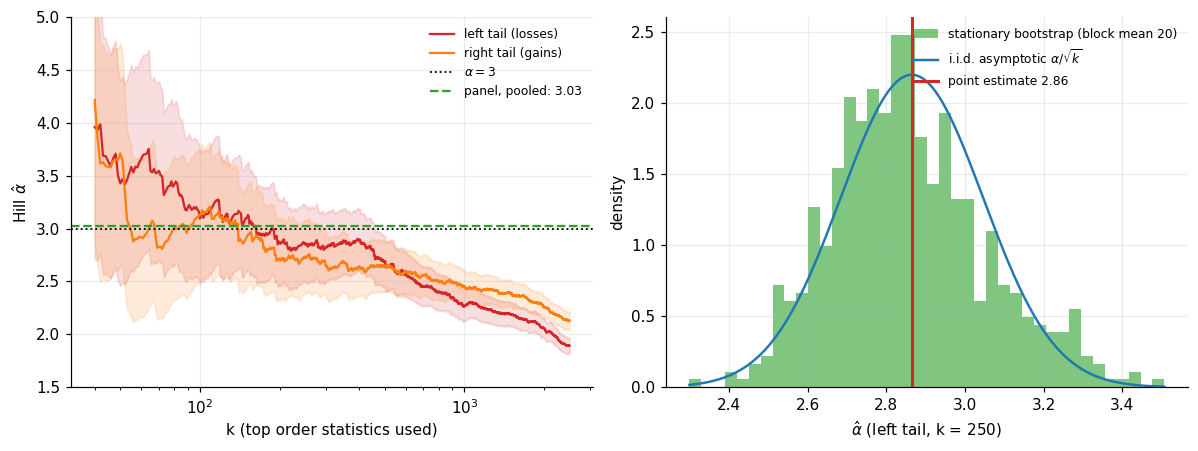

,left alpha,left se,right alpha,right se,right - left,se of diff
k,,,,,,
100,3.095,0.309,3.123,0.312,0.028,0.440
250,2.865,0.181,2.734,0.173,-0.131,0.250
500,2.691,0.120,2.650,0.118,-0.042,0.169
1000,2.264,0.072,2.453,0.078,0.188,0.106


left tail, k=250: alpha = 2.865   i.i.d. se 0.181   stationary-bootstrap sd 0.195  (90% CI [2.56, 3.22])
extremal index at the 99th percentile: 0.181 -> the 247 exceedances there are worth about 45 independent ones


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2)
kL, aL, seL = hill_plot(Lg[Lg > 0], 40, 2500)
kR, aR, seR = hill_plot(-Lg[-Lg > 0], 40, 2500)
for k_, a_, se_, c_, lab in ((kL, aL, seL, C3, "left tail (losses)"),
                             (kR, aR, seR, C1, "right tail (gains)")):
    ax1.semilogx(k_, a_, color=c_, lw=1.5, label=lab)
    ax1.fill_between(k_, a_ - 2 * se_, a_ + 2 * se_, color=c_, alpha=.15)
ax1.axhline(3, color="k", ls=":", lw=1.2, label=r"$\alpha = 3$")
ax1.axhline(alpha_pooled, color=C2, ls="--", lw=1.5,
            label=f"panel, pooled: {alpha_pooled:.2f}")
ax1.set(xlabel="k (top order statistics used)", ylabel=r"Hill $\hat\alpha$", ylim=(1.5, 5))
ax1.legend(fontsize=8)

boot = stationary_bootstrap(-Lg, 20.0, 600, np.random.default_rng(5))
al_boot = np.array([hill(-b[-b > 0], 250) for b in boot])
point = hill(Lg[Lg > 0], 250)
ax2.hist(al_boot, bins=40, color=C2, alpha=.6, density=True,
         label="stationary bootstrap (block mean 20)")
xg = np.linspace(al_boot.min(), al_boot.max(), 200)
ax2.plot(xg, np.exp(-0.5 * ((xg - point) / (point / np.sqrt(250)))**2) /
         ((point / np.sqrt(250)) * np.sqrt(2 * np.pi)), color=C0, lw=1.6,
         label=r"i.i.d. asymptotic $\alpha/\sqrt{k}$")
ax2.axvline(point, color=C3, lw=2, label=f"point estimate {point:.2f}")
ax2.set(xlabel=r"$\hat\alpha$ (left tail, k = 250)", ylabel="density")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

rows = []
for k in (100, 250, 500, 1000):
    a_l, a_r = hill(Lg[Lg > 0], k), hill(-Lg[-Lg > 0], k)
    rows.append({"k": k, "left alpha": a_l, "left se": a_l / np.sqrt(k),
                 "right alpha": a_r, "right se": a_r / np.sqrt(k),
                 "right - left": a_r - a_l, "se of diff": np.hypot(a_l, a_r) / np.sqrt(k)})
display(pd.DataFrame(rows).set_index("k").round(3))
theta = extremal_index(Lg, float(np.quantile(Lg, .99)))
print(f"left tail, k=250: alpha = {point:.3f}   i.i.d. se {point/np.sqrt(250):.3f}   "
      f"stationary-bootstrap sd {al_boot.std():.3f}  "
      f"(90% CI [{np.percentile(al_boot,5):.2f}, {np.percentile(al_boot,95):.2f}])")
print(f"extremal index at the 99th percentile: {theta:.3f} -> the "
      f"{int(0.01*NG)} exceedances there are worth about {0.01*NG*theta:.0f} independent ones")

From the plot to the left we see that **the cubic law roughly works on the market too (kinda).**

By reading the the Hill plot right to left we find that both tails sit near $3$ at small $k$ — $3.10$ left, $3.12$ right at $k = 100$ — and drift downward as $k$ grows, reaching $2.26$ and $2.45$ by $k = 1000$. That drift is what we have discussed before, i.e., the body being pulled into a tail estimate, exactly as $|t(3)|$ did in Part 4 of the simulation lab.

Furthermore, **the inter-dependence correction is not big (right plot).** Indeed, at  $k = 250$ the textbook interval is $2.87 \pm 0.181$. If we apply a resampling in geometric blocks of mean length $20$ (preserving volatility clustering) we widen the standard deviation only to $0.195$, about $8\%$. On the sixteen-year window the same exercise costs nearly $30\%$. The difference is that $98$ years contains *many* independent crises, whilst sixteen years contains essentially one, and blocking it matters enormously. **Length buys independence, not just observations.**

The extremal index is instead not softened by length. At the $99$th percentile $\theta = 0.181$, so the $247$ exceedances up there are worth roughly **$45$ independent ones**. We can safely say that 1929-33, 1987 and 2008 are not $247$ pieces of evidence about the tail, but rather they are a few dozen episodes.

Regarding symmetry instead we see that **no asymmetry emrges in the far tail".** The two tails of this market are the same size as far out as we can see,
whatever the shoulders do.

### 1c — Does aggregating five hundred stocks thin the tail?

We now apply the same toolkit to both a typical S&P constituent, and the index those constituents make up. The index is an average of hundreds of names, so the naive expectation is that averaging should thin a tail.

Let us check, on a matched window so that the comparison is not contaminated by the long history's extra data.

In [10]:
cmp = pd.DataFrame({
    "typical stock (median of 216)": [
        xs["MAD/STD"].median(), xs["R4"].median(), xs["ES99/sd left"].median(), xs["kappa(1,30)"].median(), xs["alpha (Hill)"].median()],
    "the index, same window": [
        mad_over_std(Lm), max_to_sum_ratio(Lm, 4)[-1], es_sigma_ratio(Lm, .01),
        kappa_bootstrap(Lm, n=30, n0=1, reps=40_000, rng=np.random.default_rng(1)),
        hill(Lm[Lm > 0], max(30, len(Lm) // 40))],
    "the index, 98 years": [
        mad_over_std(Lg), max_to_sum_ratio(Lg, 4)[-1], es_sigma_ratio(Lg, .01),
        kappa_bootstrap(Lg, n=30, n0=1, reps=40_000, rng=np.random.default_rng(1)),
        hill(Lg[Lg > 0], 250)],
    "Gaussian": [GAUSS_MADSTD, 0.0, GAUSS_ES_SD, 0.0, np.inf],
}, index=["MAD/STD (lower = fatter)", "R4", "ES99/sd", "kappa(1,30)", "alpha (Hill)"])
display(cmp.round(4))

fat = ["MAD/STD (lower = fatter)", "R4", "ES99/sd", "kappa(1,30)"]
worse = sum((cmp.loc[m, "the index, same window"] < cmp.loc[m, "typical stock (median of 216)"])
            if m.startswith("MAD") else
            (cmp.loc[m, "the index, same window"] > cmp.loc[m, "typical stock (median of 216)"])
            for m in fat)
print(f"on a matched window, the index is FATTER than the median stock on {worse} of the {len(fat)} "
      f"fat-tail measures")
print(f"and the tail exponents agree: panel pooled {alpha_pooled:.2f}, "
      f"index {hill(Lm[Lm>0], max(30,len(Lm)//40)):.2f} (16y) / {hill(Lg[Lg>0],250):.2f} (98y)")

,typical stock (median of 216),"the index, same window","the index, 98 years",Gaussian
MAD/STD (lower = fatter),0.6847,0.6606,0.6378,0.7979
R4,0.2007,0.2788,0.2522,0.0000
ES99/sd,4.0158,4.1637,4.3753,2.6652
"kappa(1,30)",0.1295,0.1813,0.2138,0.0000
alpha (Hill),3.0521,2.8569,2.8648,inf


on a matched window, the index is FATTER than the median stock on 4 of the 4 fat-tail measures
and the tail exponents agree: panel pooled 3.03, index 2.86 (16y) / 2.86 (98y)


Well, the answer is very sad. But makes sense. **No. Aggregation does not thin the tail, and leaves the exponent exactly where it was.** I mean, with a bit of thinking this is obsvious. 

Assume we have two independent random variables $X_1$ and $X_2$ (ours are not but jsut stay with me). Now assume $X_1$ is thin-tailed and $X_2$ is fat-tailed. Then, necessarily the sum variable $X: = X_1 + X_2$ must be fat-tailed. This is because at the tail one of the two variables completely disappears. Now, if we sum instead two fat-tailed ones, the leading one is going to be (at the very far end) that with heaviest tail index. This is immediately generalised to $N$ variables of course. So no, summing fat-tailed variables does not reduce the tails. **Diversification is going to remove only the idiosyncratic thin-tailed risk!**

Hre, in particular we see on the matched 2010- window, against the median of $216$ individual stocks:

| | typical stock | the index |
| :-- | --: | --: |
| MAD/STD (lower = fatter) | 0.685 | **0.661** |
| $R_4$ | 0.201 | **0.279** |
| kurtosis | 13.2 | **16.5** |
| $\mathrm{ES}_{99}/\sigma$ | 4.02 | **4.16** |
| $\kappa(1,30)$ | 0.129 | **0.181** |
| $\hat\alpha$ | 3.05 | 2.86 |

The index is fatter on **all five** preasymptotic measures (as it gets more contributions from the fattest of the names). And the tail exponent is essentially
unchanged: $3.03$ pooled across the panel against $2.86$ for the index, on either window, i.e., a difference of well under one standard error of the index estimate ($\pm 0.18$). **Averaging five hundred stocks leaves $\alpha$ where it was and makes $\kappa$ worse by two thirds with respect to the median stock.**

## Part 2 — EVT on the market

In this Part we carry on working entirely on `MKT` (i.e., the `^GSPC` cash index over $98$ years) and on `MKT_WIN`, the same index restricted to the panel's 2010- window. Here, we aim to ask **how often does a loss of a given size arrive**. Such a question needs *time*, so `MKT` it is.

This choice gives us something rare (under the assumption of fari comparison), namely **a genuine out-of-sample test with a known answer.**

Nineteen October 1987 delivered a $-22.9\%$ day. Our 2010-2026 window does not contain it, nor it does not contain anything close to it. Indeed, its own worst day is $-12.8\%$. So we can fit a tail to the modern window, extrapolate a factor of two beyond everything it has ever seen, ask "how often should a day
like 1987 happen?", and then check the answer against ninety-eight years of record. This is really cool.

In [11]:
# Same objects as Part 1b, restated here so the cell stands alone.
Lg = MKT.values                                # OBJECT 2: ^GSPC, 98 years of losses
Lm = MKT_WIN.values                            # the same index, 2010- window only
NG, sdg = len(Lg), Lg.std()
W = Lg.max()                                   # the worst day on record: 1987-10-19

def wait_hill(x, k, level):
    """Years between days worse than `level`, from a pure-Pareto tail fitted above X_(k+1)."""
    xp = np.sort(x[x > 0])[::-1]
    a, u = hill(x[x > 0], k), xp[k]
    return 1.0 / ((k / len(x)) * (level / u) ** (-a)) / 252, a

def wait_pot(x, q, level):
    u = float(np.quantile(x, q)); y = x[x > u] - u
    xi, b = fit_gpd(y)
    p = (y.size / len(x)) * (1 + xi * (level - u) / b) ** (-1 / xi)
    return 1.0 / p / 252, 1 / xi

rows = []
for k in (100, 250, 500):
    t, a = wait_hill(Lm, k, W)
    rows.append({"method": f"Hill, k={k}", "fitted on": "2010- (16y)", "alpha": a, "years": t})
for k in (100, 250, 500):
    t, a = wait_hill(Lg, k, W)
    rows.append({"method": f"Hill, k={k}", "fitted on": "1927- (98y)", "alpha": a, "years": t})
for q in (.975, .99, .995):
    t, a = wait_pot(Lg, q, W)
    rows.append({"method": f"POT-GPD, u=q{100*q:g}", "fitted on": "1927- (98y)", "alpha": a, "years": t})
mx = block_maxima(Lg, 252); xi_g, mu_g, sg_g = fit_gev(mx)
p_ann = 1 - np.exp(-(1 + xi_g * (W - mu_g) / sg_g) ** (-1 / xi_g))
rows.append({"method": "GEV, annual maxima", "fitted on": "1927- (98y)",
             "alpha": 1 / xi_g, "years": 1 / p_ann})

pred = pd.DataFrame(rows).set_index("method")
pred["vs observed"] = pred["years"] / (NG / 252)
print(f"a {100*W:.2f}% day: observed ONCE in {NG/252:.0f} years of record\n")
display(pred.round(2))

a 22.90% day: observed ONCE in 98 years of record



,fitted on,alpha,years,vs observed
method,,,,
"Hill, k=100",2010- (16y),2.96,143.77,1.46
"Hill, k=250",2010- (16y),2.51,57.62,0.59
"Hill, k=500",2010- (16y),1.76,9.09,0.09
"Hill, k=100",1927- (98y),3.09,121.56,1.24
"Hill, k=250",1927- (98y),2.86,87.36,0.89
"Hill, k=500",1927- (98y),2.69,64.61,0.66
"POT-GPD, u=q97.5",1927- (98y),5.03,344.30,3.50
"POT-GPD, u=q99",1927- (98y),5.81,422.08,4.29
"POT-GPD, u=q99.5",1927- (98y),8.69,741.05,7.53


**The last column gives us the predicted return period divided by the observed $98$ years, so $1.0$ is a perfect call. Unfortunately, no one is perfect.**

But we see a series of really interesting findings:

1. **Hill gets it right from sixteen years of data (provided $k$ is small).** Fitted on 2010-2026 alone, a window whose worst day is $-12.8\%$, the pure-Pareto tail at $k = 100$ says a $-22.9\%$ day arrives every **$144$ years**. Observed: one in $98$. That is an extrapolation a factor of two beyond
the largest observation in the sample, landing within a factor of $1.5$ of the truth. However, **it degrades fast as $k$ grows**. To wit, on the short window $k=250$ gives $58$ years and $k = 500$ gives $9$, because $500$ of $4{,}194$ observations is $12\%$ of the sample, i.e., not a tail at all. On the long history the same $k$ values give $122$, $87$, $65$: all sensible, because $500$ of $24{,}786$ still *is* the tail. **The quantity that matters is $k/n$, not $k$**.

2. **GEV on annual maxima also gets it right**: $79$ years, by a completely different route, with just one observation per year, $98$ data points in total, no threshold chosen at all.

3. **The peaks-over-threshold GPD fit misses every time! And in the worst possible direction (the one that makes you feel good).** 

This is a bit of a surprise (especially given the simulation lab!). POT is the more flexible model, it is also what the literature recommends. And yet, this toad, on the one occasion we can check it against reality fails. Why, o Dea Fortuna, you hate us so much? Let us investigate!

So, let us beginning by asking: *where does the tail actually live?* From the simulation lab's we now that "which threshold" is settled by looking for the region where the shape parameter $\xi$ stops moving and the *modified scale* $\beta^* = \beta - \xi u$ goes flat. Both should be constant above the threshold where the GPD approximation becomes valid. Let us actually check,
rather than choosing the 95th percentile because it sound alright.

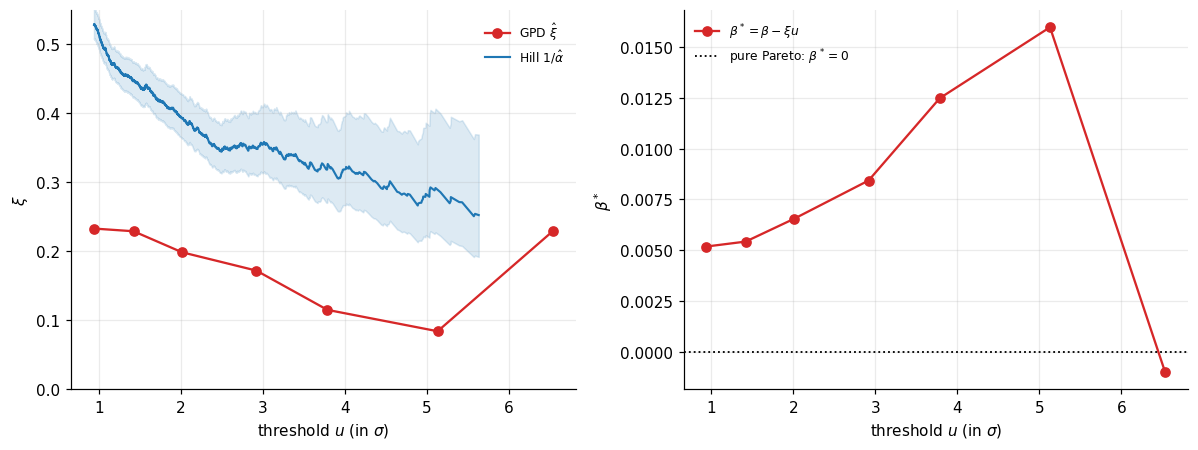

,u,u / sd,exceedances,xi,alpha = 1/xi,beta*,beta* if Pareto
quantile,,,,,,,
0.900,0.01122,0.94081,2479,0.23296,4.29255,0.00518,0.0
0.950,0.01694,1.41972,1240,0.22908,4.36533,0.00543,0.0
0.975,0.02398,2.00994,620,0.19863,5.03440,0.00655,0.0
0.990,0.03481,2.91782,248,0.17201,5.81359,0.00843,0.0
0.995,0.04516,3.78520,124,0.11505,8.69174,0.01248,0.0
0.998,0.06120,5.12983,50,0.08405,11.89775,0.01597,0.0
0.999,0.07794,6.53298,25,0.22900,4.36677,-0.00099,0.0


In [12]:
qs = [.90, .95, .975, .99, .995, .998, .999]
uu, xis, bstar, nexc = threshold_stability(Lg, np.quantile(Lg, qs), min_count=20)
stab = pd.DataFrame({"quantile": qs[:len(uu)], "u": uu, "u / sd": uu / sdg,
                     "exceedances": nexc, "xi": xis, "alpha = 1/xi": 1 / xis,
                     "beta*": bstar}).set_index("quantile")
stab["beta* if Pareto"] = 0.0

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(stab["u / sd"], stab["xi"], "o-", color=C3, label=r"GPD $\hat\xi$")
kk, aa, ss = hill_plot(Lg[Lg > 0], 40, 2500)
xp = np.sort(Lg[Lg > 0])[::-1]
ax1.plot(xp[kk] / sdg, 1 / aa, "-", color=C0, lw=1.4, label=r"Hill $1/\hat\alpha$")
ax1.fill_between(xp[kk] / sdg, 1 / (aa + 2 * ss), 1 / (aa - 2 * ss), color=C0, alpha=.15)
ax1.set(xlabel=r"threshold $u$ (in $\sigma$)", ylabel=r"$\xi$", ylim=(0, .55))
ax1.legend(fontsize=8)
ax2.plot(stab["u / sd"], stab["beta*"], "o-", color=C3, label=r"$\beta^* = \beta - \xi u$")
ax2.axhline(0, color="k", ls=":", lw=1.2, label=r"pure Pareto: $\beta^* = 0$")
ax2.set(xlabel=r"threshold $u$ (in $\sigma$)", ylabel=r"$\beta^*$")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(stab.round(5))

we can immediately see that **the stability plot is not, well, stable. Bingo.**

From the left panel we see that $\hat\xi$ falls monotonically from $0.233$ at the $90$th percentile to $0.084$ at the $99.8$th, i.e., $\hat\alpha$ *rises* from $4.3$ to $11.9$ as we move further into the tail — before jumping back to $0.229$ on the last $25$ points, where it means nothing. A GPD tail would give a flat line. So would a Pareto one. Here, we do not see that. As a further check, the left panel puts the Hill estimate on the same axes, and they diverge as expected given the previous results on the return period measured against 1987.

The right panel explains why such a difference is present. For a *pure Pareto* tail, we have $\beta = \xi u$ exactly, so that $\beta^* = 0$ at every threshold. But this is the assumption of Hill, since it fits a one-parameter power law to the ratios $X/u$. Our $\beta^*$ is not zero. It is positive and *growing*: $+0.0054$, $+0.0084$, $+0.0125$ as $u$ rises. The excesses carry systematically more scale than a power law allows, because the GPD's second parameter is free to absorb the curvature of the near-tail. And in doing so, the fit reports a thinner $\xi$ than the far tail actually has.

**So the extra flexibility of the GPD is not free.** In-sample it fits better. However, out-of-sample, over a $6.6\times$ extrapolation in $x$, that flexibilityends up describing the shoulders and it distorts the exponent that governs everything beyond them. 

None of which means "use Hill". It means the two models disagree about a region where we have $248$ observations and are extrapolating far past all of them, and **the disagreement, not either number, is the finding.** Let us look at how uncertain each of them actually is. A number without an error means nothing after all.

As stated in the checklist, here we must **report $\xi$, not $\alpha$**, since $\alpha=1/\xi$ would turn a symmetric-looking interval into an absurd one. And **use profile-likelihood intervals**, because at these exceedance counts the Wald interval misses high far more often than it advertises.

There is also a correction we have to account for and we have been putting off. These exceedances are *clustered*. Fitting a GPD to them as though they were independent is the classic mistake, and the runs declustering from the simulation lab is the classic repair we will adopt here.

In [13]:
u = float(np.quantile(Lg, .99))
y = Lg[Lg > u] - u
xi_raw, b_raw = fit_gpd(y)
lo_raw, hi_raw = gpd_profile_ci(y, .95, grid=120, span=0.5)

peaks, _ = decluster(Lg, u, runs=5)
yd = peaks - u
xi_dc, b_dc = fit_gpd(yd)
lo_dc, hi_dc = gpd_profile_ci(yd, .95, grid=120, span=0.6)
theta = extremal_index(Lg, u)

xp = np.sort(Lg[Lg > 0])[::-1]
xi_hill = 1.0 / hill(Lg[Lg > 0], y.size)

rows = []
for nm, xi_, lo_, hi_, nn_ in (("GPD, raw exceedances", xi_raw, lo_raw, hi_raw, y.size),
                               ("GPD, declustered", xi_dc, lo_dc, hi_dc, yd.size)):
    se = np.sqrt((1 + xi_) ** 2 / nn_)
    rows.append({"fit": nm, "n": nn_, "xi": xi_,
                 "profile 95%": f"[{lo_:.3f}, {hi_:.3f}]",
                 "Wald 95%": f"[{xi_-1.96*se:.3f}, {xi_+1.96*se:.3f}]",
                 "alpha = 1/xi": 1 / xi_,
                 "alpha from profile": f"[{1/hi_:.2f}, {1/lo_:.2f}]",
                 "covers Hill's xi?": bool(lo_ <= xi_hill <= hi_)})
display(pd.DataFrame(rows).set_index("fit"))

print(f"threshold u = {u:.4f} ({u/sdg:.2f} sd), the 99th percentile")
print(f"Hill at the same k: xi = {xi_hill:.4f}  (alpha = {1/xi_hill:.3f})")
print(f"extremal index at u: {theta:.3f}  ->  mean cluster size {1/theta:.1f}; "
      f"{y.size} exceedances collapse to {yd.size} independent peaks")
print(f"\nprofile interval asymmetry (raw): upper arm {hi_raw-xi_raw:.4f} vs lower arm {xi_raw-lo_raw:.4f}")

,n,xi,profile 95%,Wald 95%,alpha = 1/xi,alpha from profile,covers Hill's xi?
fit,,,,,,,
"GPD, raw exceedances",248,0.172011,"[0.042, 0.344]","[0.026, 0.318]",5.813586,"[2.90, 23.95]",False
"GPD, declustered",139,0.206895,"[0.041, 0.464]","[0.006, 0.408]",4.833366,"[2.15, 24.69]",True


threshold u = 0.0348 (2.92 sd), the 99th percentile
Hill at the same k: xi = 0.3502  (alpha = 2.856)
extremal index at u: 0.181  ->  mean cluster size 5.5; 248 exceedances collapse to 139 independent peaks

profile interval asymmetry (raw): upper arm 0.1723 vs lower arm 0.1303


As per usual, a flurry of results: 

1. **The interval on $\xi$ makes sense whilst the interval on $\alpha$ is a (not funny) joke.** The raw fit gives $\xi = 0.172$ with a profile interval of $[0.042, 0.344]$ wide but alright. Invert it and $\alpha \in [2.90, 23.95]$. **The data are consistent with a tail exponent anywhere from "infinite fourth moment" to "essentially Gaussian for any practical purpose."** 

2. **The profile interval is visibly asymmetric**, with an upper arm of $0.172$ against a lower of $0.130$, leaning, as always, toward the heavier tail. 

3. **Declustering reconciles the two estimators.** The extremal index at this threshold is $\theta = 0.181$, i.e., the mean cluster size $5.5$, and the $248$ exceedances collapse to $139$ genuinely independent peaks. By refitting on the declustered peaks we see that $\xi$ rises from $0.172$ to $0.207$, moving toward Hill. But, do notice oh dear reader (and myself), that the important change is the interval, which widens to $[0.041, 0.464]$ and **now covers Hill's $\xi = 0.350$, which the raw interval did not. Now uncertainty is more honest.**

So, given all we know now. Let us look at the **return levels**, i.e., the loss exceeded once every $T$ years ($z_T$). It is an extrapolation with $\xi$ in the exponent, so the disagreement we have just documented shows up here magnified. Let us see.

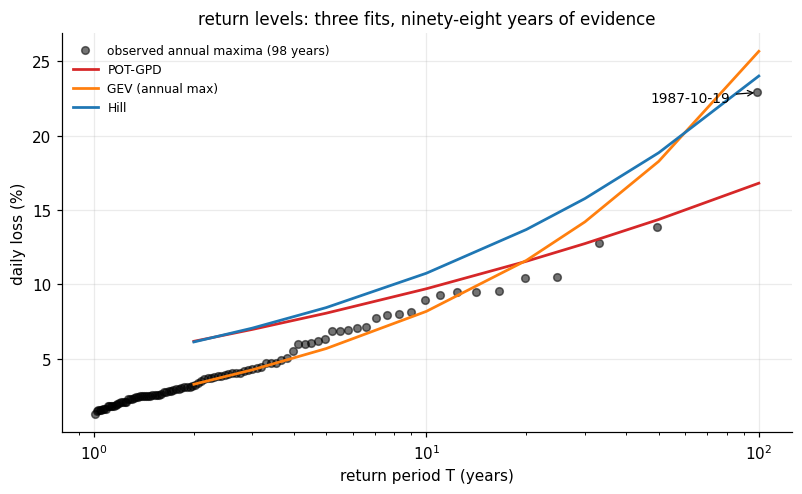

,POT-GPD,GEV (annual max),Hill
T (years),,,
2,6.17%,3.28%,6.13%
3,6.97%,4.25%,7.06%
5,8.06%,5.68%,8.44%
10,9.70%,8.18%,10.75%
20,11.55%,11.61%,13.69%
30,12.74%,14.20%,15.77%
50,14.36%,18.27%,18.85%
100,16.80%,25.67%,24.01%


observed: worst of 98 annual maxima = 22.90% at an empirical return period of 99 years


In [14]:
Ts = np.array([2, 3, 5, 10, 20, 30, 50, 100])
a_h, k_h = hill(Lg[Lg > 0], 250), 250
u_h = xp[k_h]
lev = pd.DataFrame({
    "T (years)": Ts,
    "POT-GPD": [pot_var_es(Lg, u, 1 / (t * 252))["var"] for t in Ts],
    "GEV (annual max)": [gev_return_level(xi_g, mu_g, sg_g, t) for t in Ts],
    "Hill": [u_h * ((k_h / NG) / (1 / (t * 252))) ** (1 / a_h) for t in Ts],
}).set_index("T (years)")

mx_sorted = np.sort(mx)[::-1]
emp_T = (len(mx) + 1) / np.arange(1, len(mx) + 1)          # Gumbel plotting positions

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.semilogx(emp_T, 100 * mx_sorted, "o", ms=5, color="k", alpha=.55,
            label=f"observed annual maxima ({len(mx)} years)")
for c_, lab in ((C3, "POT-GPD"), (C1, "GEV (annual max)"), (C0, "Hill")):
    ax.semilogx(Ts, 100 * lev[lab], "-", lw=1.8, color=c_, label=lab)
ax.annotate("1987-10-19", (99, 100 * W), xytext=(-70, -6), textcoords="offset points",
            fontsize=9, arrowprops=dict(arrowstyle="->", lw=.8))
ax.set(xlabel="return period T (years)", ylabel="daily loss (%)",
       title="return levels: three fits, ninety-eight years of evidence")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
display(lev.apply(lambda s: s.map("{:.2%}".format)))
print(f"observed: worst of {len(mx)} annual maxima = {100*W:.2f}% at an empirical return period "
      f"of {(len(mx)+1)/1:.0f} years")

**That is one JUICY plot.**

At $T = 100$ years the three fits say $16.80\%$ (POT), $25.67\%$ (GEV) and $24.01\%$ (Hill). The observed rank-one annual maximum is $22.90\%$ at an empirical return period of $99$ years. GEV and Hill get it roughly right but POT sits a third below it, and its curve is visibly flattening away from the data
in the top decade of the plot.

However, we must also note where POT does *best*, namely, at $T = 2$ to $10$ years. There, it tracks the observed maxima closely, better than GEV does at $T=2$. **The GPD fit is not a bad model. It is a good model of the region it was fitted to**, which is the $99$th to $99.8$th percentile, and a poor extrapolator beyond it since the $\beta^*$ curvature it absorbed does not persist.

The practical rule that falls out is as follows: **the range over which you fit and the range over which you extrapolate should not differ by an order of magnitude.** If one needs the 100-year level, use a method that is estimating the far tail — e.g., the top few hundred order statistics, or the annual maxima — rather than one that is optimising fit over the shoulders.

Now the numbers we really need to look at.

In [15]:
rows = []
for p in (0.05, 0.01, 0.001, 0.0001):
    emp = var_es_empirical(Lg, p); gau = var_es_gaussian(Lg, p); pot = pot_var_es(Lg, u, p)
    a_, u_ = hill(Lg[Lg > 0], 250), xp[250]
    var_h = u_ * ((250 / NG) / p) ** (1 / a_)
    rows.append({"p": p, "days in tail": emp["n_tail"],
                 "VaR empirical": emp["var"], "VaR Gaussian": gau["var"],
                 "VaR POT": pot["var"], "VaR Hill": var_h,
                 "ES empirical": emp["es"], "ES Gaussian": gau["es"], "ES POT": pot["es"],
                 "ES Hill": var_h * es_var_ratio(a_),
                 "ES Hill / Gaussian": var_h * es_var_ratio(a_) / gau["es"]})
risk = pd.DataFrame(rows).set_index("p")
var_cols = ["VaR empirical", "VaR Gaussian", "VaR POT", "VaR Hill"]
var_tab = risk[var_cols].apply(lambda s: s.map("{:.2%}".format))
var_tab.insert(0, "days in tail", risk["days in tail"].astype(int))
display(var_tab)
display(risk[["ES empirical", "ES Gaussian", "ES POT", "ES Hill", "ES Hill / Gaussian"]].round(4))

,days in tail,VaR empirical,VaR Gaussian,VaR POT,VaR Hill
p,,,,,
0.0500,1240,1.69%,1.94%,1.45%,1.99%
0.0100,248,3.48%,2.75%,3.48%,3.48%
0.0010,25,7.79%,3.66%,7.56%,7.78%
0.0001,3,11.78%,4.41%,13.61%,17.39%


,ES empirical,ES Gaussian,ES POT,ES Hill,ES Hill / Gaussian
p,,,,,
0.0500,0.0290,0.0244,0.0277,0.0305,1.2526
0.0100,0.0522,0.0316,0.0522,0.0535,1.6963
0.0010,0.0999,0.0399,0.1014,0.1196,2.9947
0.0001,0.1651,0.0470,0.1746,0.2671,5.6852


These are the real numbers we have to look at when sizing a portfolio, and oh boy are they not a marvel.

**At the $1\%$ level everything agrees and nothing is really at stake.** Empirical, POT and Hill all give $\mathrm{VaR}_{99} \approx 3.5\%$ against the Gaussian's $2.75\%$. Mind you the Gaussian is $21\%$ light, which is bad but survivable. **At $p = 0.01\%$ the Gaussian says $4.41\%$ and Hill says $17.39\%$.** A factor of $3.9$. The empirical estimate, computed from the *three* observations out there, says $11.78\%$, and it cannot say more. Note aslo that POT gives $13.61\%$ here, i.e., *above* the empirical figure. This just follows from the fact that the GPD's problem is the far-tail rate, not an inability to extrapolate at all.

The $\mathrm{ES}$ columns carry the same message but harder. Expected shortfall is the average loss *given* that you are past the threshold, so it lives entirely in the region we know least about. At $p = 0.01\%$ it is $4.70\%$ under the Gaussian against $26.71\%$ under Hill, a factor of **$5.7$**. And the last column shows that the ratio grows monotonically with depth, $1.25 \to 1.70 \to 2.99 \to 5.69$. **The Gaussian is wrong in a way that worsens exactly as the stakes rise.**